# 1000张图像的空间特征

基于神经元响应与多种模型特征，构造 1000 张图像在高维空间中的表示，并用 PCA 可视化（PC1-2/3/4/5/6），每页一个 scatter plot，保存为 PDF。

In [14]:
from __future__ import annotations

import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path("/media/ubuntu/sda/TrippleN")
STIMULI_DIR = ROOT / "stimuli"
CAPTIONS_PATH = ROOT / "customize" / "coco_captions_1000x5.pkl"
PSTH_PATH = ROOT / "customize" / "aggregate_response" / "all_subjects_psth.npy"
UNIT_INFO_PATH = ROOT / "customize" / "aggregate_response" / "all_subjects_unit_info.pkl"

OUT_DIR = ROOT / "customize" / "space_characteristic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /media/ubuntu/sda/TrippleN/customize/space_characteristic


In [15]:
unit_info_tuning = pd.read_pickle("/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl")
unit_info_tuning['Body_selectivity'] = (unit_info_tuning['B_SI'] > 0.3).astype(int)
unit_info_tuning['Face_selectivity'] = (unit_info_tuning['F_SI'] > 0.3).astype(int)
unit_info_tuning['Object_selectivity'] = (unit_info_tuning['O_SI'] > 0.3).astype(int)

In [16]:
def compute_neuron_responses_1000(
    psth_path: Path,
    unit_info_path: Path,
    out_npy: Path,
    n_images: int = 1000,
) -> tuple[np.ndarray, pd.DataFrame]:
    psth_data = np.load(str(psth_path), mmap_mode="r")
    unit_info = pd.read_pickle(unit_info_path)

    n_neurons, n_stimuli, n_time = psth_data.shape
    best_r_time1 = unit_info["best_r_time1"].values
    best_r_time2 = unit_info["best_r_time2"].values

    neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)

    for neuron_idx in range(n_neurons):
        start_time = int(best_r_time1[neuron_idx])
        end_time = int(best_r_time2[neuron_idx])

        if start_time < 0:
            start_time = 0
        if end_time > n_time:
            end_time = n_time
        if end_time <= start_time:
            mid_time = n_time // 2
            start_time = max(0, mid_time - 5)
            end_time = min(n_time, mid_time + 5)

        psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
        neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)

    responses_1000 = neuron_responses[:, :n_images]
    np.save(out_npy, responses_1000.astype(np.float32))
    return responses_1000, unit_info


def load_or_compute_neuron_responses_1000(
    cache_path: Path,
    psth_path: Path,
    unit_info_path: Path,
    n_images: int = 1000,
) -> tuple[np.ndarray, pd.DataFrame]:
    if cache_path.exists():
        responses_1000 = np.load(cache_path)
        unit_info = pd.read_pickle(unit_info_path)
        return responses_1000, unit_info

    return compute_neuron_responses_1000(
        psth_path=psth_path,
        unit_info_path=unit_info_path,
        out_npy=cache_path,
        n_images=n_images,
    )


NEURON_RESPONSES_1000_PATH = OUT_DIR / "neuron_responses_1000_by_best_window.npy"
responses_1000_neurons_by_images, unit_info = load_or_compute_neuron_responses_1000(
    cache_path=NEURON_RESPONSES_1000_PATH,
    psth_path=PSTH_PATH,
    unit_info_path=UNIT_INFO_PATH,
    n_images=1000,
)

print("responses_1000 shape (neurons, images):", responses_1000_neurons_by_images.shape)
print("unit_info shape:", unit_info.shape)

responses_1000 shape (neurons, images): (15652, 1000)
unit_info shape: (15652, 21)


In [17]:
def pca_scatter_pdf(
    X_samples_by_features: np.ndarray,
    out_pdf: Path,
    title: str,
    n_components: int = 6,
    dot_size: float = 6.0,
    alpha: float = 0.65,
) -> dict:
    X = np.asarray(X_samples_by_features)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(Xz)
    evr = pca.explained_variance_ratio_

    out_pdf.parent.mkdir(parents=True, exist_ok=True)

    with PdfPages(out_pdf) as pdf:
        for k in range(2, n_components + 1):
            fig, ax = plt.subplots(figsize=(6.5, 6.0))
            ax.scatter(Z[:, 0], Z[:, k - 1], s=dot_size, alpha=alpha, linewidths=0)

            ax.set_xlabel(f"PC1 ({evr[0]*100:.2f}%)")
            ax.set_ylabel(f"PC{k} ({evr[k-1]*100:.2f}%)")
            ax.set_title(title)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    return {"explained_variance_ratio": evr, "pca": pca, "scaler": scaler}


X_neuron = responses_1000_neurons_by_images.T
out_pdf_neuron = OUT_DIR / "space_neuron_responses_PCA_scatter_PC1_vs_PC2to6.pdf"
res_neuron = pca_scatter_pdf(
    X_samples_by_features=X_neuron,
    out_pdf=out_pdf_neuron,
    title="Neuron responses (1000 images) PCA scatter",
)

print("saved:", out_pdf_neuron)
print("EVR (PC1-6):", np.round(res_neuron["explained_variance_ratio"], 4))

saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/space_neuron_responses_PCA_scatter_PC1_vs_PC2to6.pdf
EVR (PC1-6): [0.1    0.0377 0.0236 0.0155 0.0138 0.0131]


In [18]:
import importlib.util

import torch

PREDICT_SCRIPT = ROOT / "scripts" / "predict_neuron_activity_gpu.py"

spec = importlib.util.spec_from_file_location("predict_neuron_activity_gpu", PREDICT_SCRIPT)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Failed to load spec for {PREDICT_SCRIPT}")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

image_files = sorted([f for f in os.listdir(STIMULI_DIR) if f.endswith(".bmp")])[:1000]
print("n_images:", len(image_files))

FEATURE_CACHE_DIR = OUT_DIR / "model_features_1000"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("ALL_MODELS:", getattr(mod, "ALL_MODELS", None))

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
n_images: 1000
ALL_MODELS: ['alexnet', 'alexnet_ae', 'clip_vit_l14_text', 'clip_vit_l14_image', 'clip_rn50_text', 'clip_rn50_image', 'clip_rn101_text', 'clip_rn101_image', 'all_mpnet_base_v2', 'dinov3_vitl16', 'dinov3_convnext_base', 'dinov3_vitb16']


In [19]:
def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def model_features_1000(model_id: str) -> np.ndarray:
    cache = FEATURE_CACHE_DIR / f"{model_id}_features_1000.npy"
    if cache.exists():
        return np.load(cache)

    if model_id == "alexnet":
        alexnet = mod.load_alexnet(device)
        feat = mod.extract_fc6_features(image_files, str(STIMULI_DIR), alexnet, device)
        del alexnet
    elif model_id == "alexnet_ae":
        alexnet_ae = mod.load_alexnet_ae(device)
        feat = mod.extract_fc6_features(image_files, str(STIMULI_DIR), alexnet_ae, device)
        del alexnet_ae
    elif model_id in ("clip_vit_l14_image", "clip_vit_l14_text"):
        clip_model, preprocess = mod.load_clip_model(
            "ViT-L-14", "/media/ubuntu/sda/TrippleN/model/ViT-L-14.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=768,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=768)
        del clip_model, preprocess
    elif model_id in ("clip_rn50_image", "clip_rn50_text"):
        clip_model, preprocess = mod.load_clip_model(
            "RN50", "/media/ubuntu/sda/TrippleN/model/RN50.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=1024,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=1024)
        del clip_model, preprocess
    elif model_id in ("clip_rn101_image", "clip_rn101_text"):
        clip_model, preprocess = mod.load_clip_model(
            "RN101", "/media/ubuntu/sda/TrippleN/model/RN101.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=512,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=512)
        del clip_model, preprocess
    elif model_id == "all_mpnet_base_v2":
        sent = mod.load_sentence_model(device)
        feat = mod.extract_caption_features(str(CAPTIONS_PATH), sent)
        del sent
    elif model_id in ("dinov3_vitl16", "dinov3_convnext_base", "dinov3_vitb16"):
        weights_path = os.path.join(mod.DINOV3_WEIGHTS_DIR, mod.DINOV3_WEIGHT_FILES[model_id])
        dim = mod.DINOV3_FEATURE_DIMS[model_id]
        m = mod.load_dinov3_model(model_id, weights_path, device)
        feat = mod.extract_dinov3_features(image_files, str(STIMULI_DIR), m, device, feature_dim=dim)
        del m
    else:
        raise ValueError(f"Unknown model_id: {model_id}")

    feat = np.asarray(feat, dtype=np.float32)
    np.save(cache, feat)
    return feat


def safe_name(s: str) -> str:
    return s.replace("/", "_").replace(" ", "_")


# plotting moved to last cell (cell 12)


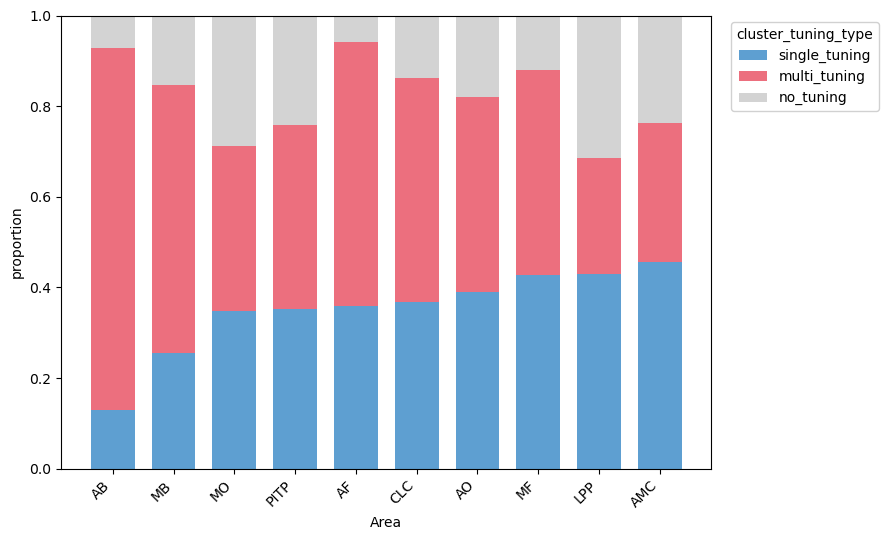

saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/cluster_tuning_type_by_area_stacked_bar.pdf


In [18]:
unit_info_tuning = pd.read_pickle("/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl")
unit_info_tuning = unit_info_tuning.copy()
if "cluster_tuning_type" not in unit_info_tuning.columns:
    raise KeyError("cluster_tuning_type 不在表中")

plot_df = unit_info_tuning.dropna(subset=["Area", "cluster_tuning_type"]).copy()
preferred = ["single_tuning", "multi_tuning", "no_tuning"]
present = plot_df["cluster_tuning_type"].unique().tolist()
order_types = [t for t in preferred if t in present]
order_types.extend(sorted(t for t in present if t not in order_types))

type_colors = {
    "no_tuning": "lightgray",
    "single_tuning": "#5E9FD1",
    "multi_tuning": "#EC6F7E",
}
extra = [t for t in order_types if t not in type_colors]
_cmap = plt.get_cmap("tab10")
for i, t in enumerate(extra):
    type_colors[t] = _cmap((i % 10) / 10.0)

counts = plot_df.groupby(["Area", "cluster_tuning_type"]).size().unstack(fill_value=0)
counts = counts.reindex(columns=order_types, fill_value=0)
row_sum = counts.sum(axis=1).replace(0, np.nan)
props = counts.div(row_sum, axis=0).fillna(0)

if "single_tuning" in props.columns:
    area_order = props.sort_values("single_tuning", ascending=True).index
else:
    area_order = props.index
props = props.reindex(area_order)
counts = counts.reindex(area_order)

fig_w = max(9, len(props) * 0.38)
fig, ax = plt.subplots(figsize=(fig_w, 5.5))
bottom = np.zeros(len(props))
x = np.arange(len(props))
for typ in order_types:
    vals = props[typ].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=typ,
        color=type_colors[typ],
        width=0.72
    )
    bottom = bottom + vals
ax.set_xticks(x)
ax.set_xticklabels(props.index.astype(str), rotation=45, ha="right")
ax.set_ylabel("proportion")
ax.set_xlabel("Area")
ax.set_ylim(0, 1)
ax.legend(title="cluster_tuning_type", bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.9)
fig.tight_layout()
out_pdf = OUT_DIR / "cluster_tuning_type_by_area_stacked_bar.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print("saved:", out_pdf)

In [4]:
import re
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image

unit_info_tuning = pd.read_pickle("/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl").copy()
responses_1000 = np.load(OUT_DIR / "neuron_responses_1000_by_best_window.npy")  # (n_units, 1000)
mu = responses_1000.mean(axis=1, keepdims=True)
sigma = responses_1000.std(axis=1, keepdims=True)
responses_1000 = (responses_1000 - mu) / (sigma + 1e-8)

image_files = sorted([f for f in os.listdir(STIMULI_DIR) if f.endswith(".bmp")])[: responses_1000.shape[1]]

if responses_1000.shape[0] != len(unit_info_tuning):
    raise ValueError(f"响应矩阵与unit_info长度不一致: {responses_1000.shape[0]} vs {len(unit_info_tuning)}")

single_mask = unit_info_tuning["cluster_tuning_type"].astype(str).eq("single_tuning").to_numpy()

if "selective_cluster_idx" in unit_info_tuning.columns:
    cluster_idx = unit_info_tuning["selective_cluster_idx"].to_numpy()
else:
    sel_cols = [c for c in unit_info_tuning.columns if re.match(r"^C\d+_selectivity$", str(c))]
    if len(sel_cols) == 0:
        raise KeyError("未找到 selective_cluster_idx 或 C*_selectivity 列")
    sel_cols = sorted(sel_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
    sel_mat = unit_info_tuning[sel_cols].to_numpy().astype(int)
    cluster_idx = np.argmax(sel_mat, axis=1)

valid_single = single_mask & np.isfinite(cluster_idx)
cluster_ids = sorted(int(c) for c in np.unique(cluster_idx[valid_single]) if int(c) >= 0)

out_pdf = OUT_DIR / "single_tuning_cluster_specific_mean_response_scatter.pdf"
summary_rows = []

with PdfPages(out_pdf) as pdf:
    for cid in cluster_ids:
        unit_idx = np.where(valid_single & (cluster_idx.astype(int) == cid))[0]
        if len(unit_idx) == 0:
            continue

        mean_resp = responses_1000[unit_idx].mean(axis=0)
        order = np.argsort(mean_resp)
        ordered_resp = mean_resp[order]

        rmin, rmax = float(np.min(ordered_resp)), float(np.max(ordered_resp))
        if rmax > rmin:
            norm_resp = (ordered_resp - rmin) / (rmax - rmin)
        else:
            norm_resp = np.zeros_like(ordered_resp)

        x = np.arange(len(norm_resp))

        topk = 15
        top_idx = order[-topk:][::-1]

        fig = plt.figure(figsize=(10, 4.5))
        gs = fig.add_gridspec(1, 2, width_ratios=[3.8, 1.2], wspace=0.25)
        ax = fig.add_subplot(gs[0, 0])
        ax.scatter(x, norm_resp, s=15, alpha=1, color="#5E9FD1", linewidths=0)
        ax.set_xlabel("image order (asc by mean response; index 0 = min)")
        ax.set_ylabel("normalized mean response")
        ax.set_title(f"cluster {cid} | single-tuning units n={len(unit_idx)}")
        ax.set_xlim(-5, 1005)
        ax.set_ylim(-0.02, 1.02)

        nrows_img, ncols_img = 5, 3
        img_gs = gs[0, 1].subgridspec(nrows_img, ncols_img, hspace=0.04, wspace=0.03)
        for rank, img_i in enumerate(top_idx):
            r = rank // ncols_img
            c = rank % ncols_img
            ax_img = fig.add_subplot(img_gs[r, c])
            img_path = STIMULI_DIR / image_files[int(img_i)]
            img = Image.open(img_path).convert("RGB")
            ax_img.imshow(img)
            ax_img.axis("off")

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)


print("saved:", out_pdf)

/tmp/ipykernel_940326/2226549065.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/single_tuning_cluster_specific_mean_response_scatter.pdf


In [9]:
from matplotlib.backends.backend_pdf import PdfPages

unit_info_tuning = pd.read_pickle('/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl').copy()
responses_1000 = np.load(OUT_DIR / 'neuron_responses_1000_by_best_window.npy')  # (n_units, 1000)

if responses_1000.shape[0] != len(unit_info_tuning):
    raise ValueError(f'响应矩阵与unit_info长度不一致: {responses_1000.shape[0]} vs {len(unit_info_tuning)}')

if 'cluster_tuning_type' not in unit_info_tuning.columns:
    raise KeyError('需要 cluster_tuning_type 列')

sel_cols = [c for c in unit_info_tuning.columns if re.match(r'^C\d+_selectivity$', str(c))]
if len(sel_cols) == 0:
    raise KeyError('需要 C*_selectivity 列来重算 selective_cluster_idx')
sel_cols = sorted(sel_cols, key=lambda x: int(re.findall(r'\d+', x)[0]))
sel_mat = unit_info_tuning[sel_cols].to_numpy().astype(int)

single_mask = unit_info_tuning['cluster_tuning_type'].astype(str).eq('single_tuning').to_numpy()
sel_count = sel_mat.sum(axis=1)
sel_cluster = np.full(len(unit_info_tuning), -1, dtype=int)
argmax_idx = np.argmax(sel_mat, axis=1)
valid_single = single_mask & (sel_count == 1)
sel_cluster[valid_single] = argmax_idx[valid_single]

rng = np.random.default_rng(0)
max_per_cluster = 150
all_cluster_ids = list(range(sel_mat.shape[1]))
cluster_ids = [cid for cid in all_cluster_ids if cid != 3]  # 用于采样/PCA
plot_cluster_ids = all_cluster_ids  # 绘图高亮包含cluster3

selected_idx_by_cluster = {}
selected_global_idx = []
cluster_label_for_selected = []

for cid in cluster_ids:
    idx = np.where(valid_single & (sel_cluster == cid))[0]
    if len(idx) == 0:
        selected = np.array([], dtype=int)
    elif len(idx) <= max_per_cluster:
        selected = idx
    else:
        selected = rng.choice(idx, size=max_per_cluster, replace=False)
    selected = np.sort(selected)
    selected_idx_by_cluster[cid] = selected
    selected_global_idx.extend(selected.tolist())
    cluster_label_for_selected.extend([cid] * len(selected))

selected_global_idx = np.asarray(selected_global_idx, dtype=int)
cluster_label_for_selected = np.asarray(cluster_label_for_selected, dtype=int)

X = responses_1000[selected_global_idx]  # (n_selected_units, 1000)
print('selected units total (exclude cluster 3):', X.shape[0])
print('per cluster:', {cid: int(len(selected_idx_by_cluster[cid])) for cid in cluster_ids})

mu = X.mean(axis=1, keepdims=True)
sd = X.std(axis=1, keepdims=True)
Xz = (X - mu) / (sd + 1e-8)

# 用于选top15图片（包含cluster3）：对全体unit先做unit-wise z-score
mu_all = responses_1000.mean(axis=1, keepdims=True)
sd_all = responses_1000.std(axis=1, keepdims=True)
responses_1000_z_all = (responses_1000 - mu_all) / (sd_all + 1e-8)

X_img = Xz.T  # (1000, n_selected_units)
pca = PCA(n_components=40, random_state=0)
pcs_img_1000x40 = pca.fit_transform(X_img)
pcs_40x1000 = pcs_img_1000x40.T
evr = pca.explained_variance_ratio_

# 每个cluster取top15图片（这里包含cluster3）
image_top15_by_cluster = {}
for cid in plot_cluster_ids:
    unit_idx_c = np.where(valid_single & (sel_cluster == cid))[0]
    if len(unit_idx_c) == 0:
        image_top15_by_cluster[cid] = np.array([], dtype=int)
        continue
    mean_resp_cluster = responses_1000_z_all[unit_idx_c].mean(axis=0)
    top15 = np.argsort(mean_resp_cluster)[-15:][::-1]
    image_top15_by_cluster[cid] = top15.astype(int)

cmap = plt.get_cmap('tab20')
cluster_colors = {cid: cmap(cid % 20) for cid in plot_cluster_ids}

out_pdf = OUT_DIR / 'k12_single_tuning_sample150_exclude_cluster3_pca40_pc1_vs_pc2to5_top15.pdf'
out_npz = OUT_DIR / 'k12_single_tuning_sample150_exclude_cluster3_pca40_data.npz'

with PdfPages(out_pdf) as pdf:
    for pc_j in [2, 3, 4, 5]:
        fig, ax = plt.subplots(figsize=(3,3))

        ax.scatter(
            pcs_img_1000x40[:, 0],
            pcs_img_1000x40[:, pc_j - 1],
            s=10,
            c='lightgray',
            alpha=0.55,
            linewidths=0,
            label='others',
        )

        for cid in plot_cluster_ids:
            top_idx = image_top15_by_cluster[cid]
            if len(top_idx) == 0:
                continue
            ax.scatter(
                pcs_img_1000x40[top_idx, 0],
                pcs_img_1000x40[top_idx, pc_j - 1],
                s=34,
                c=[cluster_colors[cid]],
                alpha=0.95,
                edgecolors='black',
                linewidths=0.25,
                label=f'C{cid} top15',
            )


        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        #ax.legend(uniq.values(), uniq.keys(), fontsize=7, ncol=3, framealpha=0.9, loc='best')

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

np.savez_compressed(
    out_npz,
    selected_global_idx=selected_global_idx,
    cluster_label_for_selected=cluster_label_for_selected,
    Xz_units_by_images=Xz,
    pcs_img_1000x40=pcs_img_1000x40,
    pcs_40x1000=pcs_40x1000,
    explained_variance_ratio=evr,
)

print('saved:', out_pdf)
print('saved:', out_npz)

selected units total (exclude cluster 3): 1545
per cluster: {0: 150, 1: 150, 2: 150, 4: 150, 5: 150, 6: 150, 7: 150, 8: 45, 9: 150, 10: 150, 11: 150}
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/k12_single_tuning_sample150_exclude_cluster3_pca40_pc1_vs_pc2to5_top15.pdf
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/k12_single_tuning_sample150_exclude_cluster3_pca40_data.npz


In [20]:
import re
from matplotlib.backends.backend_pdf import PdfPages

unit_info_tuning = pd.read_pickle('/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl').copy()
responses_1000 = np.load(OUT_DIR / 'neuron_responses_1000_by_best_window.npy')  # (n_units, 1000)

if responses_1000.shape[0] != len(unit_info_tuning):
    raise ValueError(f'响应矩阵与unit_info长度不一致: {responses_1000.shape[0]} vs {len(unit_info_tuning)}')

if 'cluster_tuning_type' not in unit_info_tuning.columns:
    raise KeyError('需要 cluster_tuning_type 列')

sel_cols = [c for c in unit_info_tuning.columns if re.match(r'^C\d+_selectivity$', str(c))]
if len(sel_cols) == 0:
    raise KeyError('需要 C*_selectivity 列来重算 selective_cluster_idx')
sel_cols = sorted(sel_cols, key=lambda x: int(re.findall(r'\d+', x)[0]))
sel_mat = unit_info_tuning[sel_cols].to_numpy().astype(int)

single_mask = unit_info_tuning['cluster_tuning_type'].astype(str).eq('single_tuning').to_numpy()
sel_count = sel_mat.sum(axis=1)
sel_cluster = np.full(len(unit_info_tuning), -1, dtype=int)
argmax_idx = np.argmax(sel_mat, axis=1)
valid_single = single_mask & (sel_count == 1)
sel_cluster[valid_single] = argmax_idx[valid_single]

rng = np.random.default_rng(0)
max_per_cluster = 150
cluster_ids = list(range(sel_mat.shape[1]))

selected_idx_by_cluster = {}
selected_global_idx = []
cluster_label_for_selected = []

for cid in cluster_ids:
    idx = np.where(single_mask & (sel_cluster == cid))[0]
    if len(idx) == 0:
        selected = np.array([], dtype=int)
    elif len(idx) <= max_per_cluster:
        selected = idx
    else:
        selected = rng.choice(idx, size=max_per_cluster, replace=False)
    selected = np.sort(selected)
    selected_idx_by_cluster[cid] = selected
    selected_global_idx.extend(selected.tolist())
    cluster_label_for_selected.extend([cid] * len(selected))

selected_global_idx = np.asarray(selected_global_idx, dtype=int)
cluster_label_for_selected = np.asarray(cluster_label_for_selected, dtype=int)

X = responses_1000[selected_global_idx]  # (n_selected_units, 1000)
print('selected units total:', X.shape[0])
print('per cluster:', {cid: int(len(selected_idx_by_cluster[cid])) for cid in cluster_ids})

mu = X.mean(axis=1, keepdims=True)
sd = X.std(axis=1, keepdims=True)
Xz = (X - mu) / (sd + 1e-8)  # unit-wise z-score
print('Xz shape (units, images):', Xz.shape)

X_img = Xz.T  # (1000, n_selected_units)
pca = PCA(n_components=40, random_state=0)
pcs_img_1000x40 = pca.fit_transform(X_img)
pcs_40x1000 = pcs_img_1000x40.T
evr = pca.explained_variance_ratio_
print('PCA scores shape (images, 40):', pcs_img_1000x40.shape)
print('PCA transposed shape (40, images):', pcs_40x1000.shape)

# 每个cluster用采样后的unit计算图片平均响应，取top15图片
image_top15_by_cluster = {}
for cid in cluster_ids:
    idx_sel = selected_idx_by_cluster[cid]
    if len(idx_sel) == 0:
        image_top15_by_cluster[cid] = np.array([], dtype=int)
        continue
    row_mask = np.where(cluster_label_for_selected == cid)[0]
    mean_resp_cluster = Xz[row_mask].mean(axis=0)
    top15 = np.argsort(mean_resp_cluster)[-15:][::-1]
    image_top15_by_cluster[cid] = top15.astype(int)

cmap = plt.get_cmap('tab20')
cluster_colors = {cid: cmap(cid % 20) for cid in cluster_ids}

out_pdf = OUT_DIR / 'k12_single_tuning_sample150_pca40_pc1_vs_pc2to5_top15.pdf'
out_npz = OUT_DIR / 'k12_single_tuning_sample150_pca40_data.npz'

with PdfPages(out_pdf) as pdf:
    for pc_j in [2, 3, 4, 5]:
        fig, ax = plt.subplots(figsize=(3,3))

        # 所有图片先画灰色
        ax.scatter(
            pcs_img_1000x40[:, 0],
            pcs_img_1000x40[:, pc_j - 1],
            s=10,
            c='lightgray',
            alpha=0.55,
            linewidths=0,
            label='others',
        )

        # 各cluster的top15高亮
        for cid in cluster_ids:
            top_idx = image_top15_by_cluster[cid]
            if len(top_idx) == 0:
                continue
            ax.scatter(
                pcs_img_1000x40[top_idx, 0],
                pcs_img_1000x40[top_idx, pc_j - 1],
                s=34,
                c=[cluster_colors[cid]],
                alpha=0.95,
                edgecolors='black',
                linewidths=0.25,
                label=f'C{cid} top15',
            )

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# 保存关键中间结果
np.savez_compressed(
    out_npz,
    selected_global_idx=selected_global_idx,
    cluster_label_for_selected=cluster_label_for_selected,
    Xz_units_by_images=Xz,
    pcs_img_1000x40=pcs_img_1000x40,
    pcs_40x1000=pcs_40x1000,
    explained_variance_ratio=evr,
)

print('saved:', out_pdf)
print('saved:', out_npz)

selected units total: 1695
per cluster: {0: 150, 1: 150, 2: 150, 3: 150, 4: 150, 5: 150, 6: 150, 7: 150, 8: 45, 9: 150, 10: 150, 11: 150}
Xz shape (units, images): (1695, 1000)
PCA scores shape (images, 40): (1000, 40)
PCA transposed shape (40, images): (40, 1000)
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/k12_single_tuning_sample150_pca40_pc1_vs_pc2to5_top15.pdf
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/k12_single_tuning_sample150_pca40_data.npz


In [21]:
import re
from typing import Any

def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def model_features_1000(model_id: str) -> np.ndarray:
    cache = FEATURE_CACHE_DIR / f"{model_id}_features_1000.npy"
    if cache.exists():
        return np.load(cache)

    if model_id == "alexnet":
        alexnet = mod.load_alexnet(device)
        feat = mod.extract_fc6_features(image_files, str(STIMULI_DIR), alexnet, device)
        del alexnet
    elif model_id == "alexnet_ae":
        alexnet_ae = mod.load_alexnet_ae(device)
        feat = mod.extract_fc6_features(image_files, str(STIMULI_DIR), alexnet_ae, device)
        del alexnet_ae
    elif model_id in ("clip_vit_l14_image", "clip_vit_l14_text"):
        clip_model, preprocess = mod.load_clip_model(
            "ViT-L-14", "/media/ubuntu/sda/TrippleN/model/ViT-L-14.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=768,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=768)
        del clip_model, preprocess
    elif model_id in ("clip_rn50_image", "clip_rn50_text"):
        clip_model, preprocess = mod.load_clip_model(
            "RN50", "/media/ubuntu/sda/TrippleN/model/RN50.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=1024,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=1024)
        del clip_model, preprocess
    elif model_id in ("clip_rn101_image", "clip_rn101_text"):
        clip_model, preprocess = mod.load_clip_model(
            "RN101", "/media/ubuntu/sda/TrippleN/model/RN101.pt", device
        )
        if model_id.endswith("_image"):
            feat = mod.extract_clip_image_features(
                image_files,
                str(STIMULI_DIR),
                clip_model,
                preprocess,
                device,
                clip_dim=512,
            )
        else:
            feat = mod.extract_clip_text_features(str(CAPTIONS_PATH), clip_model, device, clip_dim=512)
        del clip_model, preprocess
    elif model_id == "all_mpnet_base_v2":
        sent = mod.load_sentence_model(device)
        feat = mod.extract_caption_features(str(CAPTIONS_PATH), sent)
        del sent
    elif model_id in ("dinov3_vitl16", "dinov3_convnext_base", "dinov3_vitb16"):
        weights_path = os.path.join(mod.DINOV3_WEIGHTS_DIR, mod.DINOV3_WEIGHT_FILES[model_id])
        dim = mod.DINOV3_FEATURE_DIMS[model_id]
        m = mod.load_dinov3_model(model_id, weights_path, device)
        feat = mod.extract_dinov3_features(image_files, str(STIMULI_DIR), m, device, feature_dim=dim)
        del m
    else:
        raise ValueError(f"Unknown model_id: {model_id}")

    feat = np.asarray(feat, dtype=np.float32)
    np.save(cache, feat)
    return feat


def safe_name(s: str) -> str:
    return s.replace("/", "_").replace(" ", "_")


def compute_cluster_top15_images() -> dict:
    ui = pd.read_pickle("/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl").copy()
    resp = np.load(OUT_DIR / "neuron_responses_1000_by_best_window.npy")

    sel_cols = [c for c in ui.columns if re.match(r"^C\d+_selectivity$", str(c))]
    sel_cols = sorted(sel_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
    if len(sel_cols) == 0:
        raise KeyError("未找到 C*_selectivity 列")

    sel_mat = ui[sel_cols].to_numpy().astype(int)
    single_mask = ui["cluster_tuning_type"].astype(str).eq("single_tuning").to_numpy()
    sel_count = sel_mat.sum(axis=1)
    sel_cluster = np.full(len(ui), -1, dtype=int)
    argmax_idx = np.argmax(sel_mat, axis=1)
    valid_single = single_mask & (sel_count == 1)
    sel_cluster[valid_single] = argmax_idx[valid_single]

    mu = resp.mean(axis=1, keepdims=True)
    sd = resp.std(axis=1, keepdims=True)
    resp_z = (resp - mu) / (sd + 1e-8)

    top15 = {}
    for cid in range(sel_mat.shape[1]):
        idx = np.where(valid_single & (sel_cluster == cid))[0]
        if len(idx) == 0:
            top15[cid] = np.array([], dtype=int)
            continue
        m = resp_z[idx].mean(axis=0)
        top15[cid] = np.argsort(m)[-15:][::-1].astype(int)
    return top15


def pca_scatter_pdf_with_top15(
    X_samples_by_features: np.ndarray,
    out_pdf: Path,
    title: str,
    top15_by_cluster: dict,
    n_components: int = 6,
) -> dict:
    X = np.asarray(X_samples_by_features)
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(Xz)
    evr = pca.explained_variance_ratio_

    cmap = plt.get_cmap("tab20")
    cluster_ids = sorted(top15_by_cluster.keys())

    with PdfPages(out_pdf) as pdf:
        for k in range(2, n_components + 1):
            fig, ax = plt.subplots(figsize=(3,3))
            ax.scatter(Z[:, 0], Z[:, k - 1], s=10, c="lightgray", alpha=0.55, linewidths=0, label="others")

            for cid in cluster_ids:
                top_idx = top15_by_cluster[cid]
                if len(top_idx) == 0:
                    continue
                ax.scatter(
                    Z[top_idx, 0],
                    Z[top_idx, k - 1],
                    s=25,
                    c=[cmap(cid % 20)],
                    alpha=0.95,
                    edgecolors="black",
                    linewidths=0.25,
                    label=f"C{cid} top15",
                )

 
            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    return {"explained_variance_ratio": evr}


MODEL_PDF_DIR = OUT_DIR / "pca_scatter_pdfs"
MODEL_PDF_DIR.mkdir(parents=True, exist_ok=True)

top15_by_cluster = compute_cluster_top15_images()
results = {}
for model_id in mod.ALL_MODELS:
    print("\n===", model_id, "===")
    X = model_features_1000(model_id)
    out_pdf = MODEL_PDF_DIR / f"space_{safe_name(model_id)}_PCA_scatter_PC1_vs_PC2to6_top15.pdf"
    r = pca_scatter_pdf_with_top15(
        X_samples_by_features=X,
        out_pdf=out_pdf,
        title=f"{model_id} (1000 images) PCA scatter + cluster top15",
        top15_by_cluster=top15_by_cluster,
    )
    results[model_id] = r["explained_variance_ratio"]
    print("saved:", out_pdf)
    print("EVR (PC1-6):", np.round(results[model_id], 4))

results


=== alexnet ===
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/pca_scatter_pdfs/space_alexnet_PCA_scatter_PC1_vs_PC2to6_top15.pdf
EVR (PC1-6): [0.0404 0.034  0.0277 0.0235 0.019  0.0172]

=== alexnet_ae ===
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/pca_scatter_pdfs/space_alexnet_ae_PCA_scatter_PC1_vs_PC2to6_top15.pdf
EVR (PC1-6): [0.0749 0.0561 0.0467 0.036  0.0287 0.0235]

=== clip_vit_l14_text ===
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/pca_scatter_pdfs/space_clip_vit_l14_text_PCA_scatter_PC1_vs_PC2to6_top15.pdf
EVR (PC1-6): [0.0726 0.0686 0.0382 0.0366 0.0339 0.0282]

=== clip_vit_l14_image ===
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/pca_scatter_pdfs/space_clip_vit_l14_image_PCA_scatter_PC1_vs_PC2to6_top15.pdf
EVR (PC1-6): [0.0542 0.0398 0.0268 0.024  0.0217 0.0205]

=== clip_rn50_text ===
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/pca_scatter_pdfs/space_clip_rn50_text_P

{'alexnet': array([0.04042643, 0.03395868, 0.02772225, 0.02348447, 0.01901969,
        0.01717032], dtype=float32),
 'alexnet_ae': array([0.0749265 , 0.05610069, 0.04670835, 0.03602475, 0.02871885,
        0.02352693], dtype=float32),
 'clip_vit_l14_text': array([0.07260647, 0.06861017, 0.03822802, 0.03656404, 0.03385147,
        0.0282264 ], dtype=float32),
 'clip_vit_l14_image': array([0.05416273, 0.0397688 , 0.02684478, 0.02398205, 0.02172946,
        0.02053686], dtype=float32),
 'clip_rn50_text': array([0.07088719, 0.0603162 , 0.03837376, 0.03580039, 0.03012964,
        0.02756862], dtype=float32),
 'clip_rn50_image': array([0.0545477 , 0.04129574, 0.02805324, 0.02459452, 0.0215583 ,
        0.01973541], dtype=float32),
 'clip_rn101_text': array([0.07528888, 0.06708343, 0.04129465, 0.03582255, 0.03210657,
        0.02996165], dtype=float32),
 'clip_rn101_image': array([0.05927396, 0.04171237, 0.03216348, 0.02543064, 0.02466608,
        0.02238335], dtype=float32),
 'all_mpnet_base

In [58]:
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
from sklearn.decomposition import PCA

unit_info_tuning = pd.read_pickle('/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl').copy()
responses_1000 = np.load(OUT_DIR / 'neuron_responses_1000_by_best_window.npy')

if responses_1000.shape[0] != len(unit_info_tuning):
    raise ValueError(f'响应矩阵与unit_info长度不一致: {responses_1000.shape[0]} vs {len(unit_info_tuning)}')

areas = ['CLC', 'AMC']
for a in areas:
    if a not in set(unit_info_tuning['Area'].astype(str).unique()):
        raise ValueError(f'未在Area中找到脑区: {a}')

mu = responses_1000.mean(axis=1, keepdims=True)
sd = responses_1000.std(axis=1, keepdims=True)
resp_z = (responses_1000 - mu) / (sd + 1e-8)

image_files = sorted([f for f in os.listdir(STIMULI_DIR) if f.endswith('.bmp')])[: resp_z.shape[1]]
if len(image_files) != resp_z.shape[1]:
    raise ValueError(f'刺激图数量与响应列数不一致: {len(image_files)} vs {resp_z.shape[1]}')

area_pca = {}
for area in areas:
    idx = np.where(unit_info_tuning['Area'].astype(str).to_numpy() == area)[0]
    if len(idx) < 2:
        raise ValueError(f'{area} unit数量不足以做PCA: {len(idx)}')
    X_img = resp_z[idx].T
    pca = PCA(n_components=2, random_state=0)
    Z = pca.fit_transform(X_img)
    area_pca[area] = {
        'Z': Z,
        'evr': pca.explained_variance_ratio_,
        'n_units': len(idx),
        'pc1_order': np.argsort(Z[:, 0]),
        'pc2_order': np.argsort(Z[:, 1]),
    }

clc_pc1_order = area_pca['CLC']['pc1_order']
cond_bins = np.array_split(clc_pc1_order, 10)
image_group_idx = np.full(len(image_files), -1, dtype=int)
for gi, b in enumerate(cond_bins):
    image_group_idx[b] = gi

def _hex2rgb01(h):
    h = h.lstrip('#')
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=float) / 255.0

def _lerp(a, b, t):
    return (1 - t) * a + t * b

c1 = _hex2rgb01('#7fa5dc')
c2 = _hex2rgb01('#6a7d58')
c3 = _hex2rgb01('#d88e45')

ts = np.linspace(0, 1, 10)
group_colors = []
for t in ts:
    if t <= 0.5:
        group_colors.append(np.clip(_lerp(c1, c2, t / 0.5), 0, 1))
    else:
        group_colors.append(np.clip(_lerp(c2, c3, (t - 0.5) / 0.5), 0, 1))

group_colors = np.asarray(group_colors)
point_colors = group_colors[image_group_idx]

def build_montage(sorted_indices, tile_w=50, tile_h=20, n_cols=40):
    n = len(sorted_indices)
    n_rows = int(np.ceil(n / n_cols))
    canvas = np.full((n_rows * tile_h, n_cols * tile_w, 3), 255, dtype=np.uint8)
    for rank, img_idx in enumerate(sorted_indices):
        r, c = divmod(rank, n_cols)
        img_path = STIMULI_DIR / image_files[int(img_idx)]
        with Image.open(img_path) as im:
            patch = np.asarray(im.convert('RGB').resize((tile_w, tile_h), Image.Resampling.BILINEAR), dtype=np.uint8)
        y0, y1 = r * tile_h, (r + 1) * tile_h
        x0, x1 = c * tile_w, (c + 1) * tile_w
        canvas[y0:y1, x0:x1] = patch
    return canvas

out_pdf = OUT_DIR / 'area_CLC_AMC_response_pca_scatter_montage.pdf'
with PdfPages(out_pdf) as pdf:
    for area in areas:
        Z = area_pca[area]['Z']
        evr = area_pca[area]['evr']
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(Z[:, 0], Z[:, 1], s=12, c=point_colors, alpha=0.8, linewidths=0)
        ax.set_xlabel(f'PC1 ({evr[0]*100:.2f}%)')
        ax.set_ylabel(f'PC2 ({evr[1]*100:.2f}%)')
        ax.set_title(f'{area} | response-space PCA on 1000 stimuli (n_units={area_pca[area]["n_units"]})')
        ax.set_aspect('equal', adjustable='box')
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    fig, axes = plt.subplots(2, 1, figsize=(20, 9))
    for i, area in enumerate(areas):
        montage = build_montage(area_pca[area]['pc1_order'], tile_w=50, tile_h=20, n_cols=40)
        axes[i].imshow(montage)
        axes[i].axis('off')
        axes[i].set_title(f'{area} stimuli sorted by PC1 (low -> high), tile=50x20')
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    fig, axes = plt.subplots(2, 1, figsize=(20, 9))
    for i, area in enumerate(areas):
        montage = build_montage(area_pca[area]['pc2_order'], tile_w=50, tile_h=20, n_cols=40)
        axes[i].imshow(montage)
        axes[i].axis('off')
        axes[i].set_title(f'{area} stimuli sorted by PC2 (low -> high), tile=50x20')
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print('saved:', out_pdf)


saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/area_CLC_AMC_response_pca_scatter_montage.pdf


In [54]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors
from sklearn.decomposition import PCA

unit_info_tuning = pd.read_pickle('/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl').copy()
responses_1000 = np.load(OUT_DIR / 'neuron_responses_1000_by_best_window.npy')

if responses_1000.shape[0] != len(unit_info_tuning):
    raise ValueError(f'响应矩阵与unit_info长度不一致: {responses_1000.shape[0]} vs {len(unit_info_tuning)}')

mu = responses_1000.mean(axis=1, keepdims=True)
sd = responses_1000.std(axis=1, keepdims=True)
resp_z = (responses_1000 - mu) / (sd + 1e-8)

image_files = sorted([f for f in os.listdir(STIMULI_DIR) if f.endswith('.bmp')])[: resp_z.shape[1]]
if len(image_files) != resp_z.shape[1]:
    raise ValueError(f'刺激图数量与响应列数不一致: {len(image_files)} vs {resp_z.shape[1]}')

clc_idx = np.where(unit_info_tuning['Area'].astype(str).to_numpy() == 'CLC')[0]
if len(clc_idx) < 2:
    raise ValueError(f'CLC unit数量不足以做PCA: {len(clc_idx)}')

X_clc_img = resp_z[clc_idx].T
pca_clc = PCA(n_components=2, random_state=0)
Z_clc = pca_clc.fit_transform(X_clc_img)
pc1_order = np.argsort(Z_clc[:, 0])

n_cond = 10
cond_bins = np.array_split(pc1_order, n_cond)
cond_labels = [f'PC1bin_{i+1}' for i in range(n_cond)]

area_list = sorted(unit_info_tuning['Area'].dropna().astype(str).unique().tolist())
if len(area_list) != 10:
    print('warning: 检测到脑区数量=', len(area_list), 'areas=', area_list)

sim_by_area = {}
units_by_area = {}
for area in area_list:
    area_idx = np.where(unit_info_tuning['Area'].astype(str).to_numpy() == area)[0]
    if len(area_idx) == 0:
        continue
    R = np.stack([resp_z[area_idx][:, b].mean(axis=1) for b in cond_bins], axis=1)
    Rm = R.mean(axis=1, keepdims=True)
    Rs = R.std(axis=1, keepdims=True)
    Rn = (R - Rm) / (Rs + 1e-8)
    S = np.corrcoef(Rn.T)
    sim_by_area[area] = S
    units_by_area[area] = int(len(area_idx))

out_dir = OUT_DIR / 'area_population_similarity'
out_dir.mkdir(parents=True, exist_ok=True)

out_npz = out_dir / 'population_similarity_pc1bin10_by_area.npz'
out_pdf = out_dir / 'population_similarity_pc1bin10_by_area.pdf'
out_csv = out_dir / 'population_similarity_pc1bin10_summary.csv'

save_payload = {
    'cond_labels': np.array(cond_labels, dtype=object),
    'pc1_order': pc1_order.astype(int),
}
for a, s in sim_by_area.items():
    save_payload[f'sim_{a}'] = s.astype(np.float32)
np.savez_compressed(out_npz, **save_payload)

rows = []
for area in area_list:
    if area not in sim_by_area:
        continue
    S = sim_by_area[area]
    tri = S[np.triu_indices_from(S, k=1)]
    rows.append({
        'Area': area,
        'n_units': units_by_area[area],
        'mean_offdiag_similarity': float(np.nanmean(tri)),
        'std_offdiag_similarity': float(np.nanstd(tri)),
    })
pd.DataFrame(rows).to_csv(out_csv, index=False)

with PdfPages(out_pdf) as pdf:
    n_area = len([a for a in area_list if a in sim_by_area])
    n_cols = 3
    n_rows = int(np.ceil(n_area / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

    cmap_custom = plt.get_cmap('coolwarm')
    norm = colors.TwoSlopeNorm(vmin=-1.0, vcenter=-0.3, vmax=1.0)

    valid_areas = [a for a in area_list if a in sim_by_area]
    for i, area in enumerate(valid_areas):
        r, c = divmod(i, n_cols)
        ax = axes[r, c]
        im = ax.imshow(sim_by_area[area], cmap=cmap_custom, norm=norm)
        ax.set_title(f'{area} (n={units_by_area[area]})')
        ax.set_xticks([])
        ax.set_yticks([])

    for j in range(len(valid_areas), n_rows * n_cols):
        r, c = divmod(j, n_cols)
        axes[r, c].axis('off')

    fig.suptitle('Population similarity matrices by Area\nConditions: 10 bins from CLC PC1 order', y=0.995)
    fig.tight_layout(rect=[0, 0, 0.95, 0.97])
    cbar_ax = fig.add_axes([0.96, 0.14, 0.015, 0.72])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-1.0, -0.3, 0.0, 0.5, 1.0])
    pdf.savefig(fig)
    plt.close(fig)

print('saved:', out_npz)
print('saved:', out_csv)
print('saved:', out_pdf)
print('areas:', area_list)
print('n_conditions:', n_cond)


saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/area_population_similarity/population_similarity_pc1bin10_by_area.npz
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/area_population_similarity/population_similarity_pc1bin10_summary.csv
saved: /media/ubuntu/sda/TrippleN/customize/space_characteristic/area_population_similarity/population_similarity_pc1bin10_by_area.pdf
areas: ['AB', 'AF', 'AMC', 'AO', 'CLC', 'LPP', 'MB', 'MF', 'MO', 'PITP']
n_conditions: 10
